In [1]:
import pandas as pd

dataset = 'retina'

experiments_df = pd.read_csv(f'{dataset}_experiments.csv')

experiments_df.groupby(['loss']).agg({'ACC': ['mean', 'std'],
                                      '1OFF': ['mean', 'std'],
                                      'MAE': ['mean', 'std'],
                                      'MSE': ['mean', 'std'],
                                      'QWK': ['mean', 'std'],
                                      'AMAE': ['mean', 'std'],
                                      'MMAE': ['mean', 'std']
                                      })

ACC                1OFF                 MAE            \
                      mean       std      mean       std      mean       std   
loss                                                                           
COPOC             0.511231  0.018904  0.760000  0.016756  0.835154  0.042815   
CrossEntropyLoss  0.480923  0.017633  0.740846  0.015343  0.891692  0.032639   

                       MSE                 QWK                AMAE            \
                      mean       std      mean       std      mean       std   
loss                                                                           
COPOC             1.784385  0.129936  0.519380  0.033705  1.001889  0.064630   
CrossEntropyLoss  1.896154  0.096610  0.398649  0.031387  1.229491  0.056566   

                      MMAE            
                      mean       std  
loss                                  
COPOC             1.582690  0.262598  
CrossEntropyLoss  2.464615  0.265088

In [2]:
experiments_df.groupby(['loss']).agg({
    'RPS': ['mean', 'std'],
    'BS': ['mean', 'std'],
    'ECE': ['mean', 'std'],
    'CONF': ['mean', 'std'],
    'UMOD': ['mean', 'std'],
    'VAR': ['mean', 'std']
})

RPS                  BS                 ECE            \
                      mean       std      mean       std      mean       std   
loss                                                                           
COPOC             0.532278  0.022566  0.596966  0.014459  0.029845  0.006096   
CrossEntropyLoss  0.559668  0.018332  0.633202  0.017802  0.065559  0.006632   

                      CONF                UMOD                 VAR            
                      mean       std      mean       std      mean       std  
loss                                                                          
COPOC             0.546242  0.010154  1.000000  0.000000  0.933091  0.020386  
CrossEntropyLoss  0.633542  0.009015  0.294769  0.019546  0.847181  0.025277

In [3]:
experiments_cp_df = pd.read_csv(f'{dataset}_experiments_cp.csv')

# Define filters
experiments_cp_df['Method'] = ""
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'LAC')] = 'LAC'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'APS')]= 'APS'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'RPS')]= 'RPS'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'min-CPS')]= 'min-CPS'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'OCDF')]= 'OCDF'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'COPOC') & (experiments_cp_df['score'] == 'LAC')] = 'COPOCL'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'COPOC') & (experiments_cp_df['score'] == 'APS')] = 'COPOCA'

print(experiments_cp_df['Method'].value_counts())

condition = (
        (experiments_cp_df['Method'] == "LAC")
        | (experiments_cp_df['Method'] == "APS")
        | (experiments_cp_df['Method'] == "RPS")
        | (experiments_cp_df['Method'] == "min-CPS")
        | (experiments_cp_df['Method'] == "COPOCL")
        | (experiments_cp_df['Method'] == "COPOCA")
        | (experiments_cp_df['Method'] == "OCDF")
)

# Apply filter
df_filt = experiments_cp_df[condition].copy()

df_filt

Method
           1500
COPOCA      500
COPOCL      500
min-CPS     500
RPS         500
OCDF        500
APS         500
LAC         500
Name: count, dtype: int64


,iteration,loss,score,ALPHA,COV,PS,MW,MAMM,WAMM,AISL,MASE,CV%,Method
30,0,COPOC,APS,0.01,0.996154,4.573077,3.573077,1.000000,1.0,4.342308,0.003846,0.000000,COPOCA
31,0,COPOC,APS,0.02,0.973077,4.030769,3.030769,1.142857,2.0,6.107692,0.030769,0.000000,COPOCA
32,0,COPOC,APS,0.03,0.973077,3.946154,2.946154,1.142857,2.0,4.997436,0.030769,0.000000,COPOCA
33,0,COPOC,APS,0.05,0.946154,3.642308,2.650000,1.642857,4.0,4.957692,0.088462,0.000000,COPOCA
34,0,COPOC,APS,0.08,0.926923,3.353846,2.365385,1.842105,4.0,4.576923,0.134615,0.000000,COPOCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,49,CrossEntropyLoss,LAC,0.10,0.930769,3.373077,2.500000,1.277778,2.0,4.038462,0.088462,0.126923,LAC
4996,49,CrossEntropyLoss,LAC,0.13,0.911538,3.096154,2.261538,1.391304,3.0,3.977515,0.123077,0.161538,LAC
4997,49,CrossEntropyLoss,LAC,0.15,0.884615,2.861538,2.053846,1.466667,3.0,4.156410,0.169231,0.176923,LAC
4998,49,CrossEntropyLoss,LAC,0.18,0.838462,2.534615,1.784615,1.476190,3.0,4.220513,0.238462,0.226923,LAC


In [4]:
res_filt = df_filt.groupby(['ALPHA', 'Method']).agg({
    'COV': ['mean', 'std'],
    'PS': ['mean', 'std'],
    'MW': ['mean', 'std'],
    'CV%': ['mean', 'std'],
    'MAMM': ['mean', 'std'],
    'WAMM': ['mean', 'std'],
    'MASE': ['mean', 'std'],
    'AISL': ['mean', 'std'],
})
res_filt.index

MultiIndex([(              0.01,     'APS'),
            (              0.01,  'COPOCA'),
            (              0.01,  'COPOCL'),
            (              0.01,     'LAC'),
            (              0.01,    'OCDF'),
            (              0.01,     'RPS'),
            (              0.01, 'min-CPS'),
            (              0.02,     'APS'),
            (              0.02,  'COPOCA'),
            (              0.02,  'COPOCL'),
            (              0.02,     'LAC'),
            (              0.02,    'OCDF'),
            (              0.02,     'RPS'),
            (              0.02, 'min-CPS'),
            (              0.03,     'APS'),
            (              0.03,  'COPOCA'),
            (              0.03,  'COPOCL'),
            (              0.03,     'LAC'),
            (              0.03,    'OCDF'),
            (              0.03,     'RPS'),
            (              0.03, 'min-CPS'),
            (              0.05,     'APS'),
          

In [5]:
res = res_filt.loc[0.0999999999999999]
res_fmt = pd.DataFrame({})
res_fmt['COV'] = res[( 'COV', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'COV',  'std')].round(3).astype(str)
res_fmt['PS'] = res[( 'PS', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'PS',  'std')].round(3).astype(str)
res_fmt['CV'] = res[( 'CV%', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'CV%',  'std')].round(3).astype(str)
res_fmt['MW'] = res[( 'MW', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'MW',  'std')].round(3).astype(str)
res_fmt['MAMM'] = res[( 'MAMM', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'MAMM',  'std')].round(3).astype(str)
res_fmt['WAMM'] = res[( 'WAMM', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'WAMM',  'std')].round(3).astype(str)
res_fmt['MASE'] = res[( 'MASE', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'MASE',  'std')].round(3).astype(str)
res_fmt['AISL'] = res[( 'AISL', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'AISL',  'std')].round(3).astype(str)
res_fmt

,COV,PS,CV,MW,MAMM,WAMM,MASE,AISL
Method,,,,,,,,
APS,0.903 \textpm 0.022,3.14 \textpm 0.136,0.182 \textpm 0.017,2.33 \textpm 0.128,1.374 \textpm 0.122,3.6 \textpm 0.7,0.134 \textpm 0.033,4.224 \textpm 0.351
COPOCA,0.902 \textpm 0.024,3.162 \textpm 0.135,0.0 \textpm 0.0,2.17 \textpm 0.132,1.577 \textpm 0.167,3.9 \textpm 0.364,0.156 \textpm 0.047,4.641 \textpm 0.516
COPOCL,0.9 \textpm 0.023,3.062 \textpm 0.131,0.0 \textpm 0.0,2.062 \textpm 0.131,1.595 \textpm 0.122,3.54 \textpm 0.542,0.158 \textpm 0.035,5.223 \textpm 0.58
LAC,0.902 \textpm 0.024,3.153 \textpm 0.159,0.143 \textpm 0.016,2.298 \textpm 0.151,1.307 \textpm 0.078,2.82 \textpm 0.388,0.129 \textpm 0.035,4.605 \textpm 0.502
OCDF,0.902 \textpm 0.024,4.364 \textpm 0.092,0.0 \textpm 0.0,3.364 \textpm 0.092,1.374 \textpm 0.077,2.44 \textpm 0.501,0.135 \textpm 0.036,6.073 \textpm 0.64
RPS,0.903 \textpm 0.02,3.257 \textpm 0.092,0.0 \textpm 0.0,2.257 \textpm 0.092,1.153 \textpm 0.048,2.0 \textpm 0.0,0.112 \textpm 0.023,4.495 \textpm 0.376
min-CPS,0.902 \textpm 0.022,3.1 \textpm 0.154,0.0 \textpm 0.0,2.1 \textpm 0.154,1.37 \textpm 0.083,2.84 \textpm 0.37,0.135 \textpm 0.033,4.796 \textpm 0.511


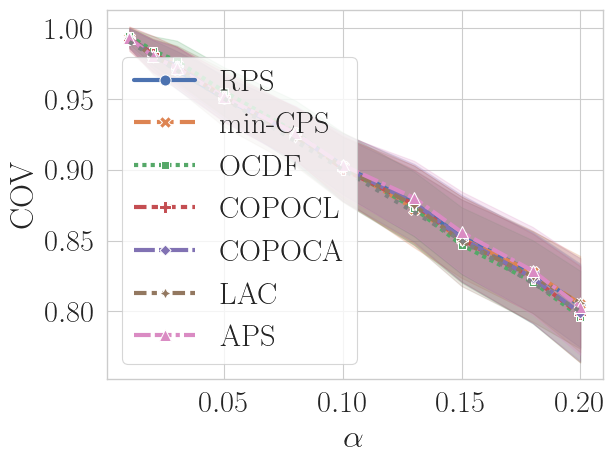

In [6]:
import seaborn as sns

sns.set_theme(context='paper', style='whitegrid', font_scale=2.5, font="serif", rc={
    "text.usetex": True,
    "lines.markersize": 8,
    "lines.linewidth": 3
})

# sns.set_theme(
#     context='paper',       # Suitable for small figure size in papers
#     style='whitegrid',     # Light grid for readability
#     font_scale=2.5,        # Slightly smaller than 2.5 for paper aesthetics
#     font='serif',          # Use serif fonts (matches LaTeX)
#     rc={
#         "text.usetex": True,           # Use LaTeX for all text
#         "font.family": "serif",        # Ensure all text uses serif
#         #"axes.labelsize": 12,          # Axis label size
#         #"axes.titlesize": 12,          # Title size
#         #"xtick.labelsize": 10,         # Tick label size
#         #"ytick.labelsize": 10,
#         #"legend.fontsize": 10,         # Legend font size
#         "lines.markersize": 6,         # Marker size
#         #"lines.linewidth": 2.5,        # Slightly thicker lines for clarity
#         #"figure.figsize": (6, 4)       # Typical paper figure size
#     }
# )


methods = ['RPS', 'min-CPS', 'OCDF', 'COPOCL','COPOCA','LAC','APS'] # ,'COPOCA','COPOCR',


g = sns.lineplot(data=df_filt, x="ALPHA", y="COV", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)

sns.lineplot(x=[0.2, 0.01], y=[0.8, 0.99], color='gray', linestyle=':')
#g.set_xticks([0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2])
#g.set_xticklabels([0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2])


g.set_xlabel('$\\alpha$')
g.set_ylabel('COV')

fig = g.get_figure()
fig.savefig(f'cov_{dataset}.pdf', bbox_inches='tight', dpi=300)

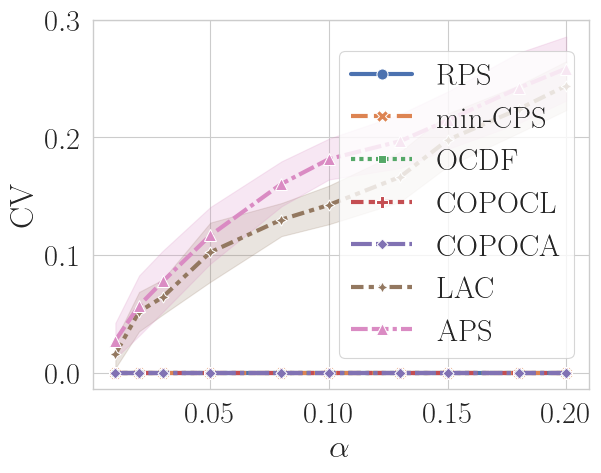

In [7]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="CV%", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.set_xlabel('$\\alpha$')
g.set_ylabel('CV')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'cv_{dataset}.pdf', bbox_inches='tight', dpi=300)

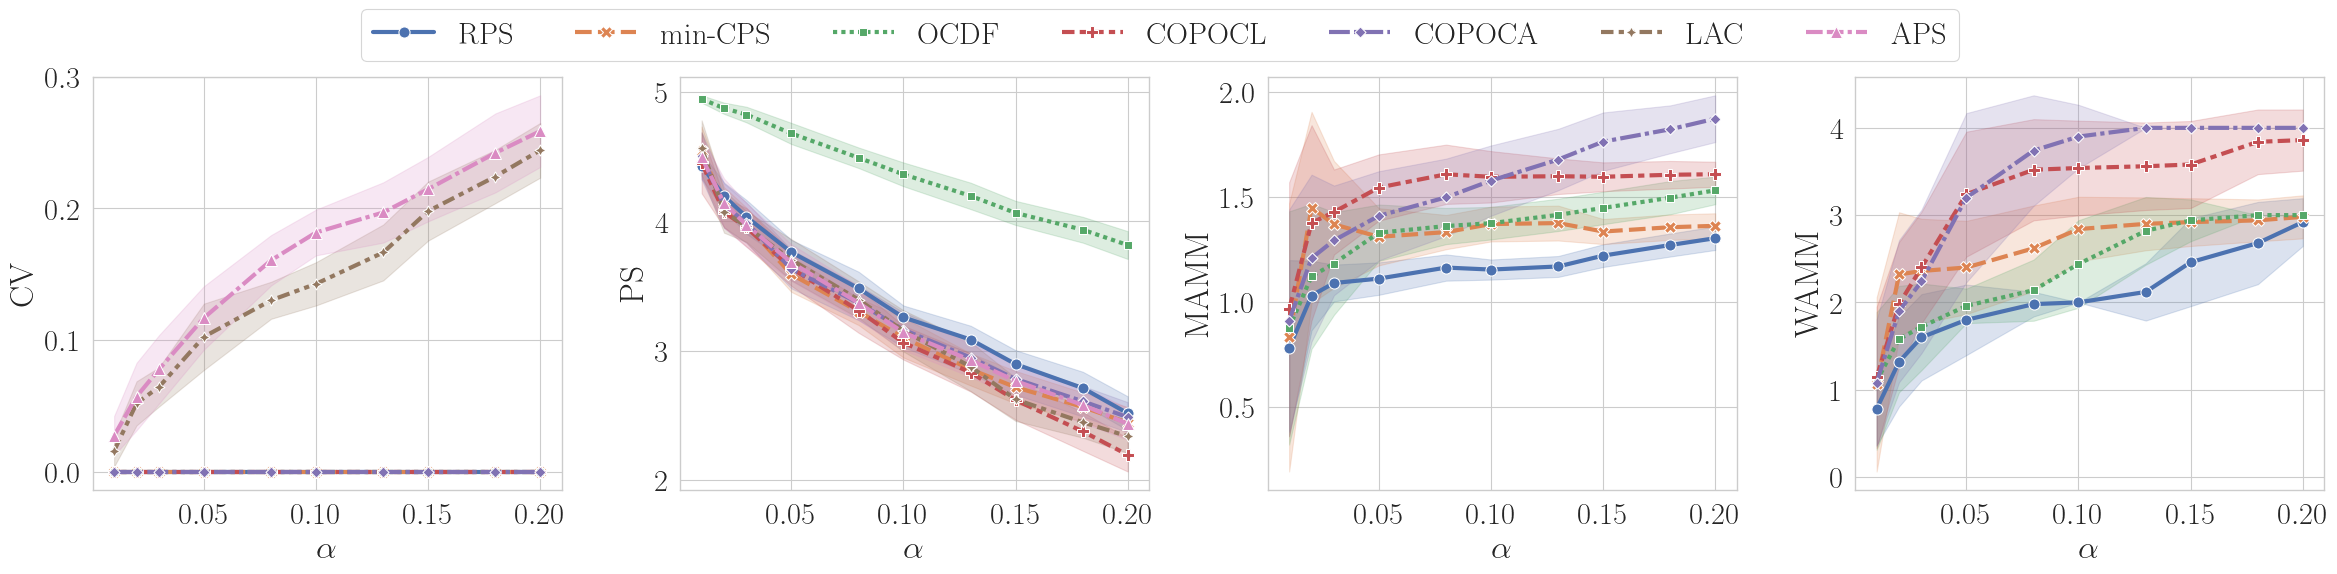

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharex=True)
metrics = [("CV%", "CV"), ("PS", "PS"), ("MAMM", "MAMM"), ("WAMM", "WAMM")]
hue_order = methods
style_order = methods

for i, (ax, (col, ylabel)) in enumerate(zip(axes, metrics)):

    if col == "MW" or col == "AISL" or  col == "MASE" or col == "MAMM" or col == "WAMM":
        if methods.count("LAC") == 1:
            methods.remove('LAC')
        if methods.count("APS") == 1:
            methods.remove('APS')
    elif col == "COV" or col== 'CV' or col=='PS':
          if methods.count("LAC") != 1:
            methods.append('LAC')
          if methods.count("APS") != 1:
            methods.append('APS')

    g = sns.lineplot(
        data=df_filt,
        x="ALPHA", y=col, hue="Method", style="Method",
        markers=True, errorbar='sd',
        hue_order=hue_order, style_order=style_order, ax=ax
    )
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()  # Legende immer entfernen

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True,bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'ord_plots_{dataset}.pdf', bbox_inches='tight', dpi=300)
plt.show()

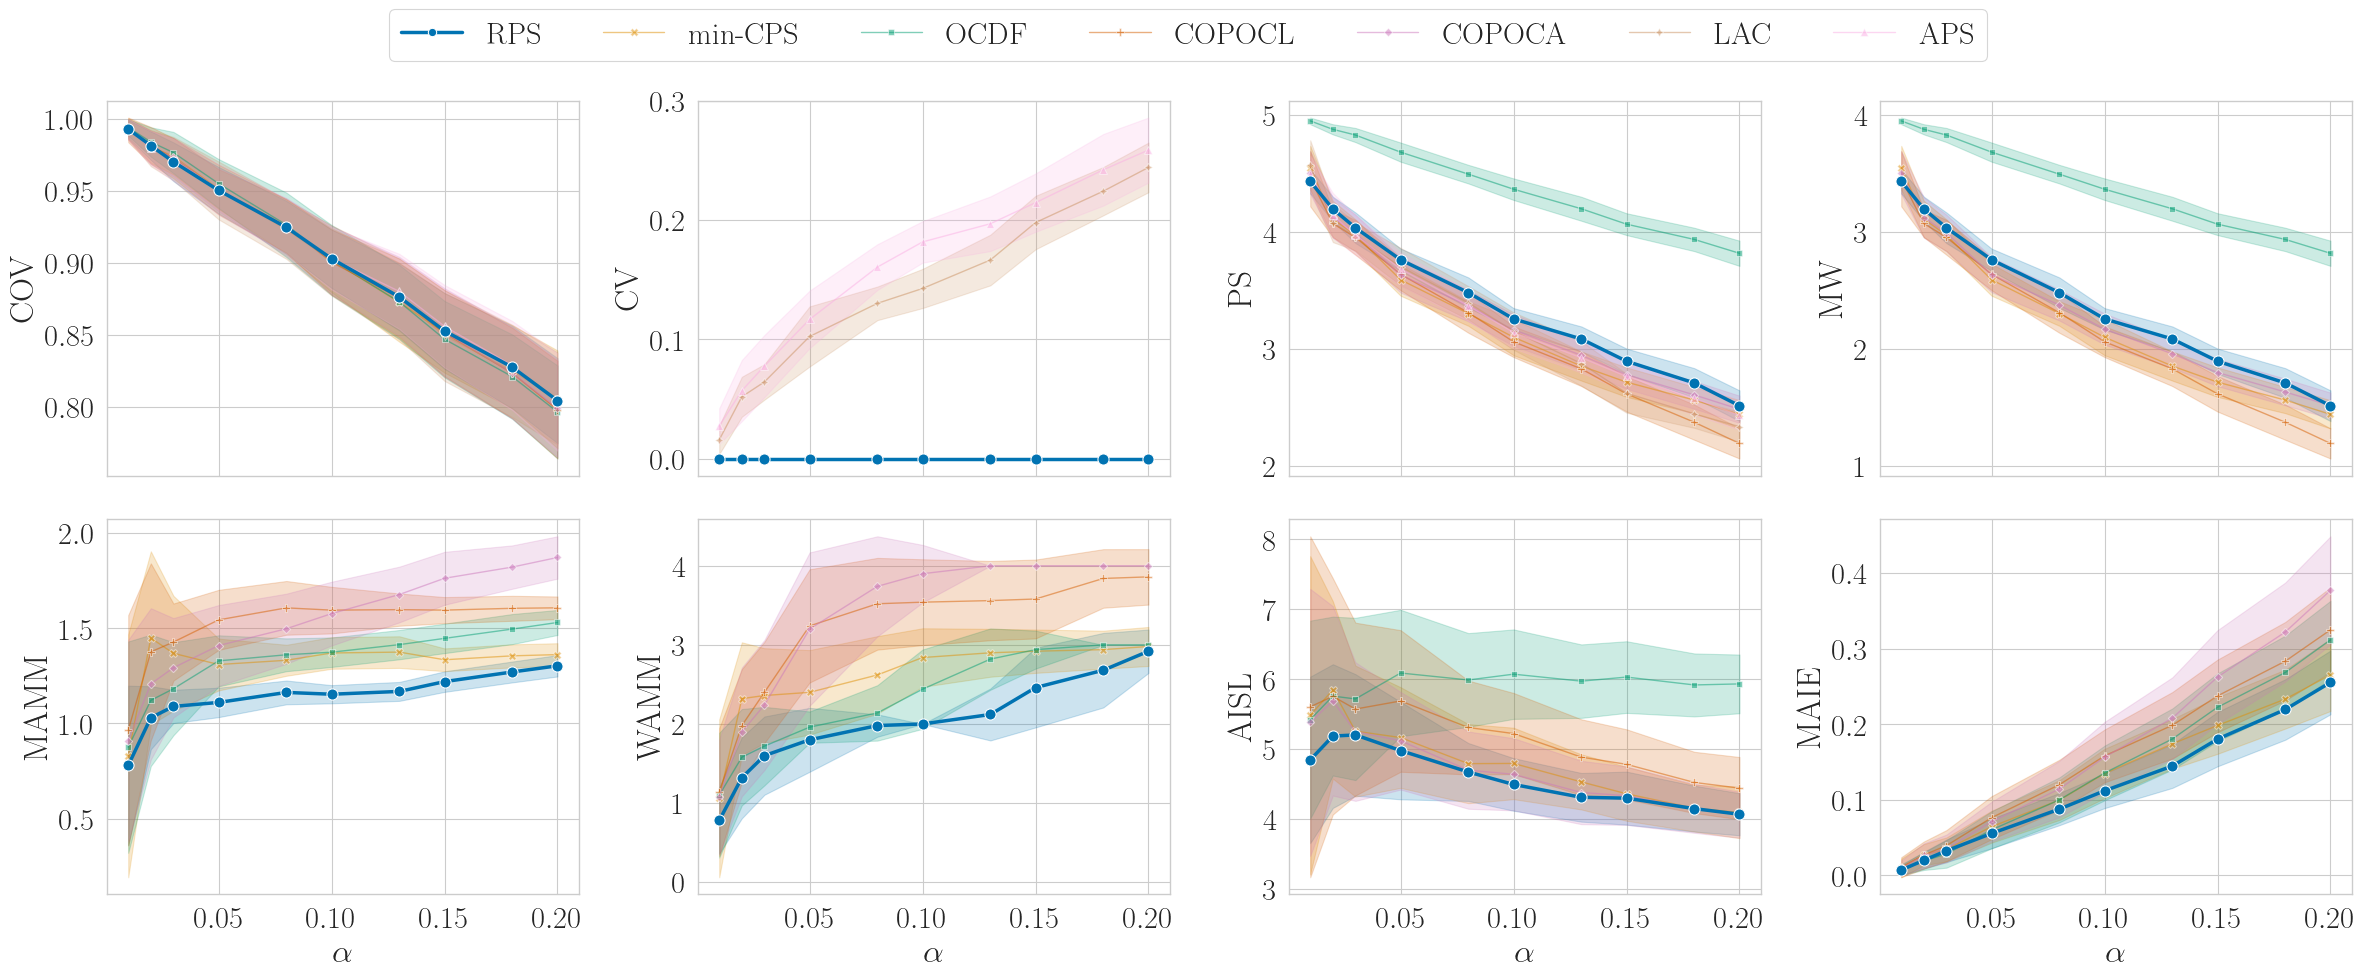

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patheffects import withStroke

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True)
axes = np.array(axes).ravel()
metrics = [("COV", "COV"), ("CV%", "CV"), ("PS", "PS"), ("MW","MW"), ("MAMM", "MAMM"), ("WAMM", "WAMM"), ("AISL", "AISL"), ("MASE", "MAIE")]

plot_methods = [m for m in methods if m not in ["LAC", "APS"]]

for i, (ax, (col, ylabel)) in enumerate(zip(axes, metrics)):

    if col == "MW" or col == "AISL" or  col == "MASE" or col == "MAMM" or col == "WAMM":
        if methods.count("LAC") == 1:
            methods.remove('LAC')
        if methods.count("APS") == 1:
            methods.remove('APS')
    elif col == "COV" or col== 'CV' or col=='PS':
          if methods.count("LAC") != 1:
            methods.append('LAC')
          if methods.count("APS") != 1:
            methods.append('APS')

    hue_order = methods
    style_order = methods

    g = sns.lineplot(
        data=df_filt,
        x="ALPHA", y=col, hue="Method", style="Method",
        markers=True, errorbar='sd',palette="colorblind",
        hue_order=hue_order, style_order=style_order, ax=ax, dashes=False
    )


    for line in ax.get_lines():
        line.set_markersize(6)
        line.set_alpha(0.5)
        line.set_linewidth(1)

    for line, label in zip(ax.get_lines(), plot_methods):
        if label == "RPS":
            line.set_markersize(8)
            line.set_linewidth(2.5)
            line.set_alpha(1.0)
            line.set_zorder(10)


    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()  # Legende immer entfernen

#handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True,bbox_to_anchor=(0.5, 1.01))


handles, labels = axes[0].get_legend_handles_labels()
for h, l in zip(handles, labels):
    if l == "RPS":
        h.set_alpha(1.0)
        h.set_linewidth(2.5)

fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True, bbox_to_anchor=(0.5, 1.01))

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'ord_plots_{dataset}_full.pdf', bbox_inches='tight', dpi=300)
plt.show()


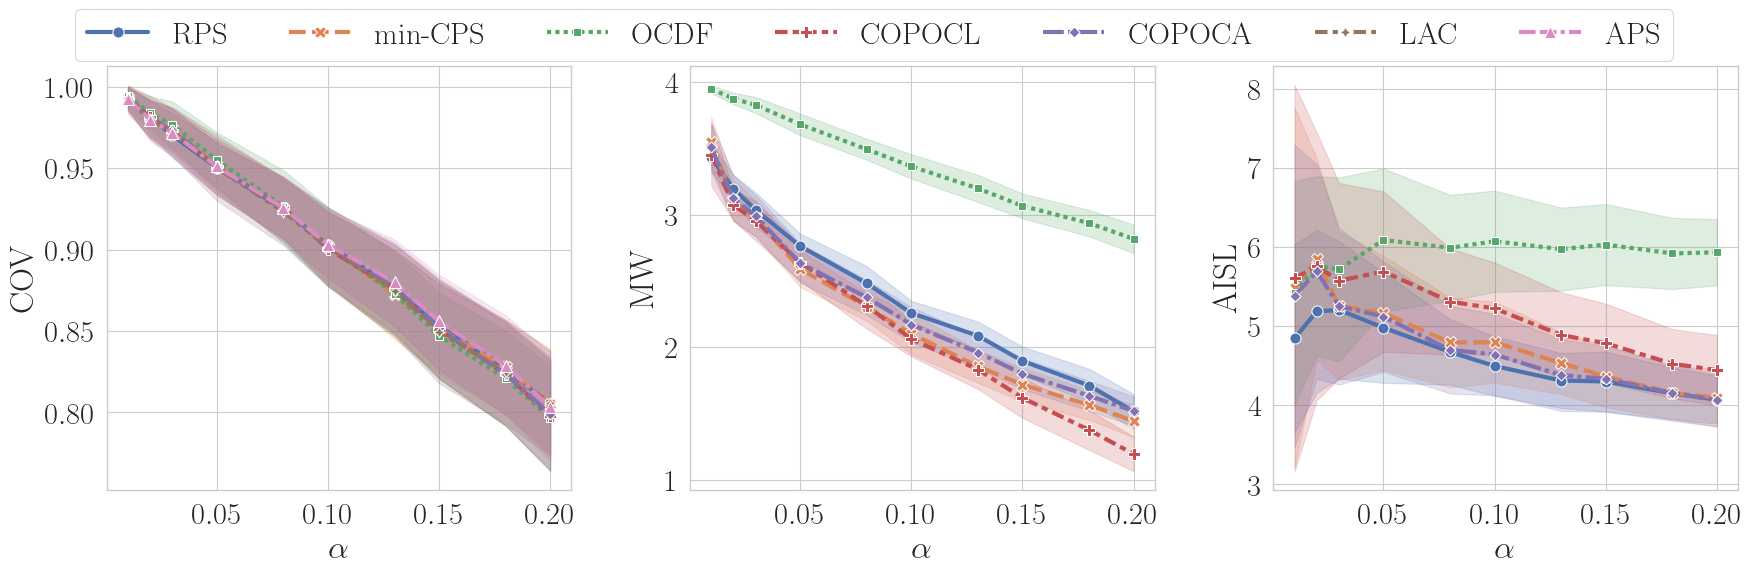

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
metrics = [("COV", "COV"), ("MW", "MW"), ("AISL", "AISL")]

for i, (ax, (col, ylabel)) in enumerate(zip(axes, metrics)):

    if col == "MW" or col == "AISL" or  col == "MASE" or col == "MAMM" or col == "WAMM":
        if methods.count("LAC") == 1:
            methods.remove('LAC')
        if methods.count("APS") == 1:
            methods.remove('APS')
    elif col == "COV" or col== 'CV' or col=='PS':
          if methods.count("LAC") != 1:
            methods.append('LAC')
          if methods.count("APS") != 1:
            methods.append('APS')

    hue_order = methods
    style_order = methods

    g = sns.lineplot(
        data=df_filt,
        x="ALPHA", y=col, hue="Method", style="Method",
        markers=True, errorbar='sd',
        hue_order=hue_order, style_order=style_order, ax=ax
    )
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()  # Legende immer entfernen

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True,bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'ord_plots_appendix_{dataset}.pdf', bbox_inches='tight', dpi=300)
plt.show()

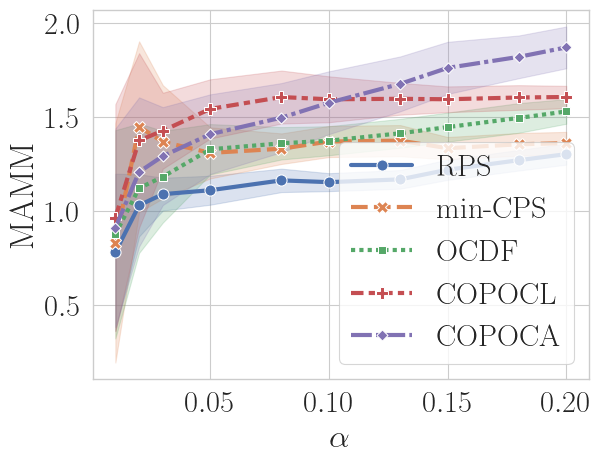

In [11]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="MAMM", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.set_xlabel('$\\alpha$')
g.set_ylabel('MAMM')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'mamm_{dataset}.pdf', bbox_inches='tight', dpi=300)

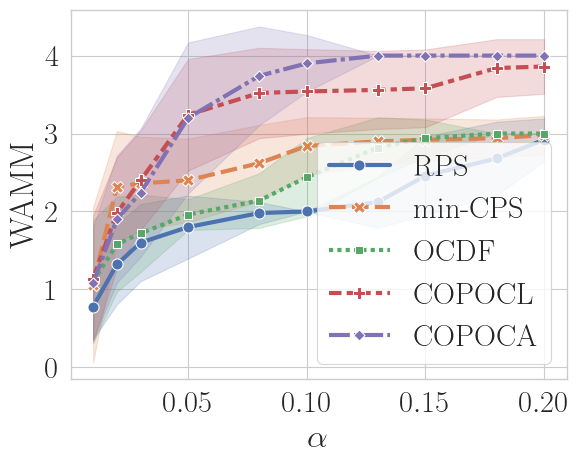

In [12]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="WAMM", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.set_xlabel('$\\alpha$')
g.set_ylabel('WAMM')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'wamm_{dataset}.pdf', bbox_inches='tight', dpi=300)

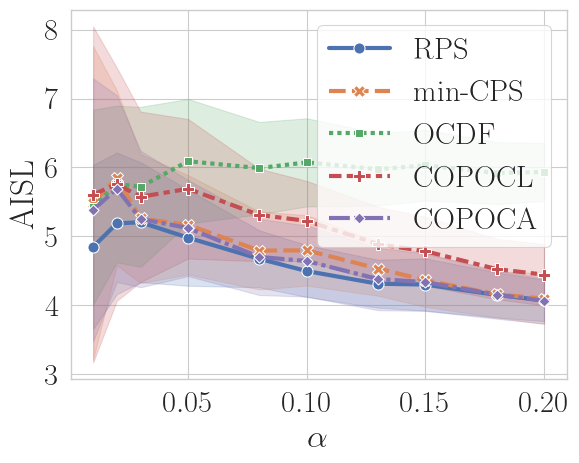

In [13]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="AISL", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.set_xlabel('$\\alpha$')
g.set_ylabel('AISL')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'aisl_{dataset}.pdf', bbox_inches='tight', dpi=300)

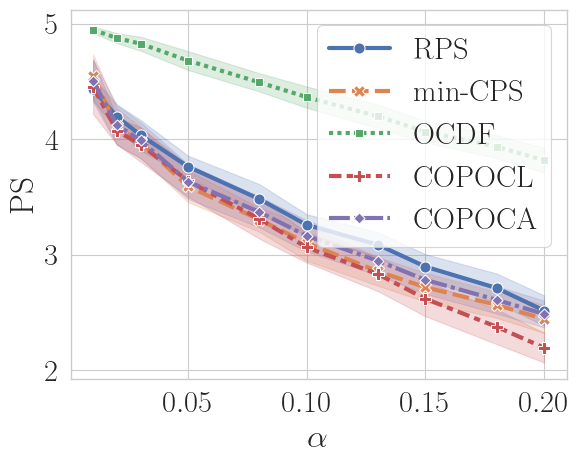

In [14]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="PS", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.get_legend().set_title('')
g.set_xlabel('$\\alpha$')
g.set_ylabel('PS')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'ps_{dataset}.pdf', bbox_inches='tight', dpi=300)

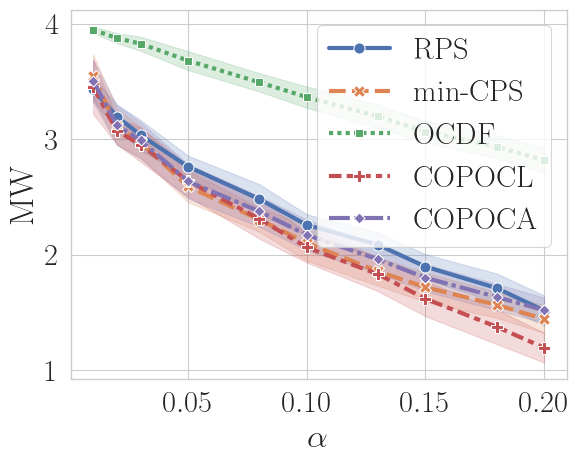

In [15]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="MW", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.get_legend().set_title('')
g.set_xlabel('$\\alpha$')
g.set_ylabel('MW')
fig = g.get_figure()
fig.savefig(f'mw_{dataset}.pdf', bbox_inches='tight', dpi=300)

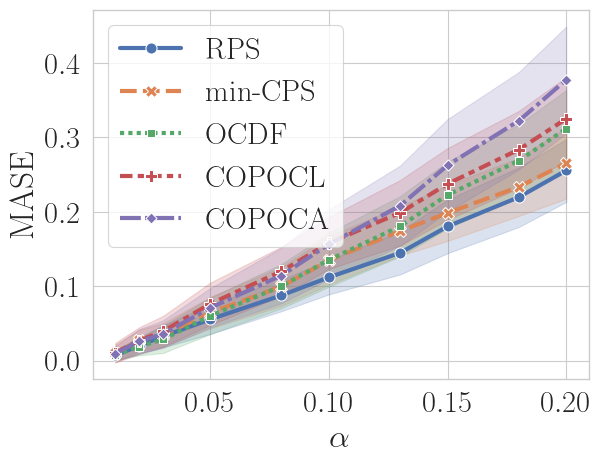

In [16]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="MASE", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.get_legend().set_title('')
g.set_xlabel('$\\alpha$')
g.set_ylabel('MASE')
fig = g.get_figure()
fig.savefig(f'mase_{dataset}.pdf', bbox_inches='tight', dpi=300)

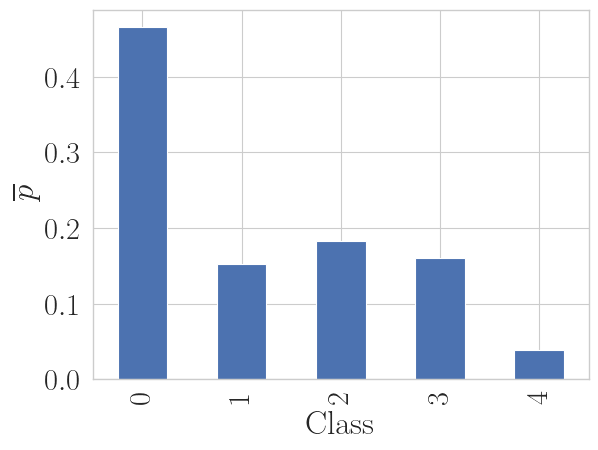

In [17]:
df_probas = pd.read_csv(f'probas_{dataset}_CrossEntropyLoss.csv', header=0, index_col=0)
g = df_probas.mean().plot(kind='bar')
g.set_xlabel('Class')
g.set_ylabel('$\\overline{p}$')
fig = g.get_figure()
fig.savefig(f'probas_{dataset}_CE.pdf', bbox_inches='tight', dpi=300)

Method
           11850
COPOCA      3950
COPOCL      3950
min-CPS     3950
RPS         3950
OCDF        3950
APS         3950
LAC         3950
Name: count, dtype: int64


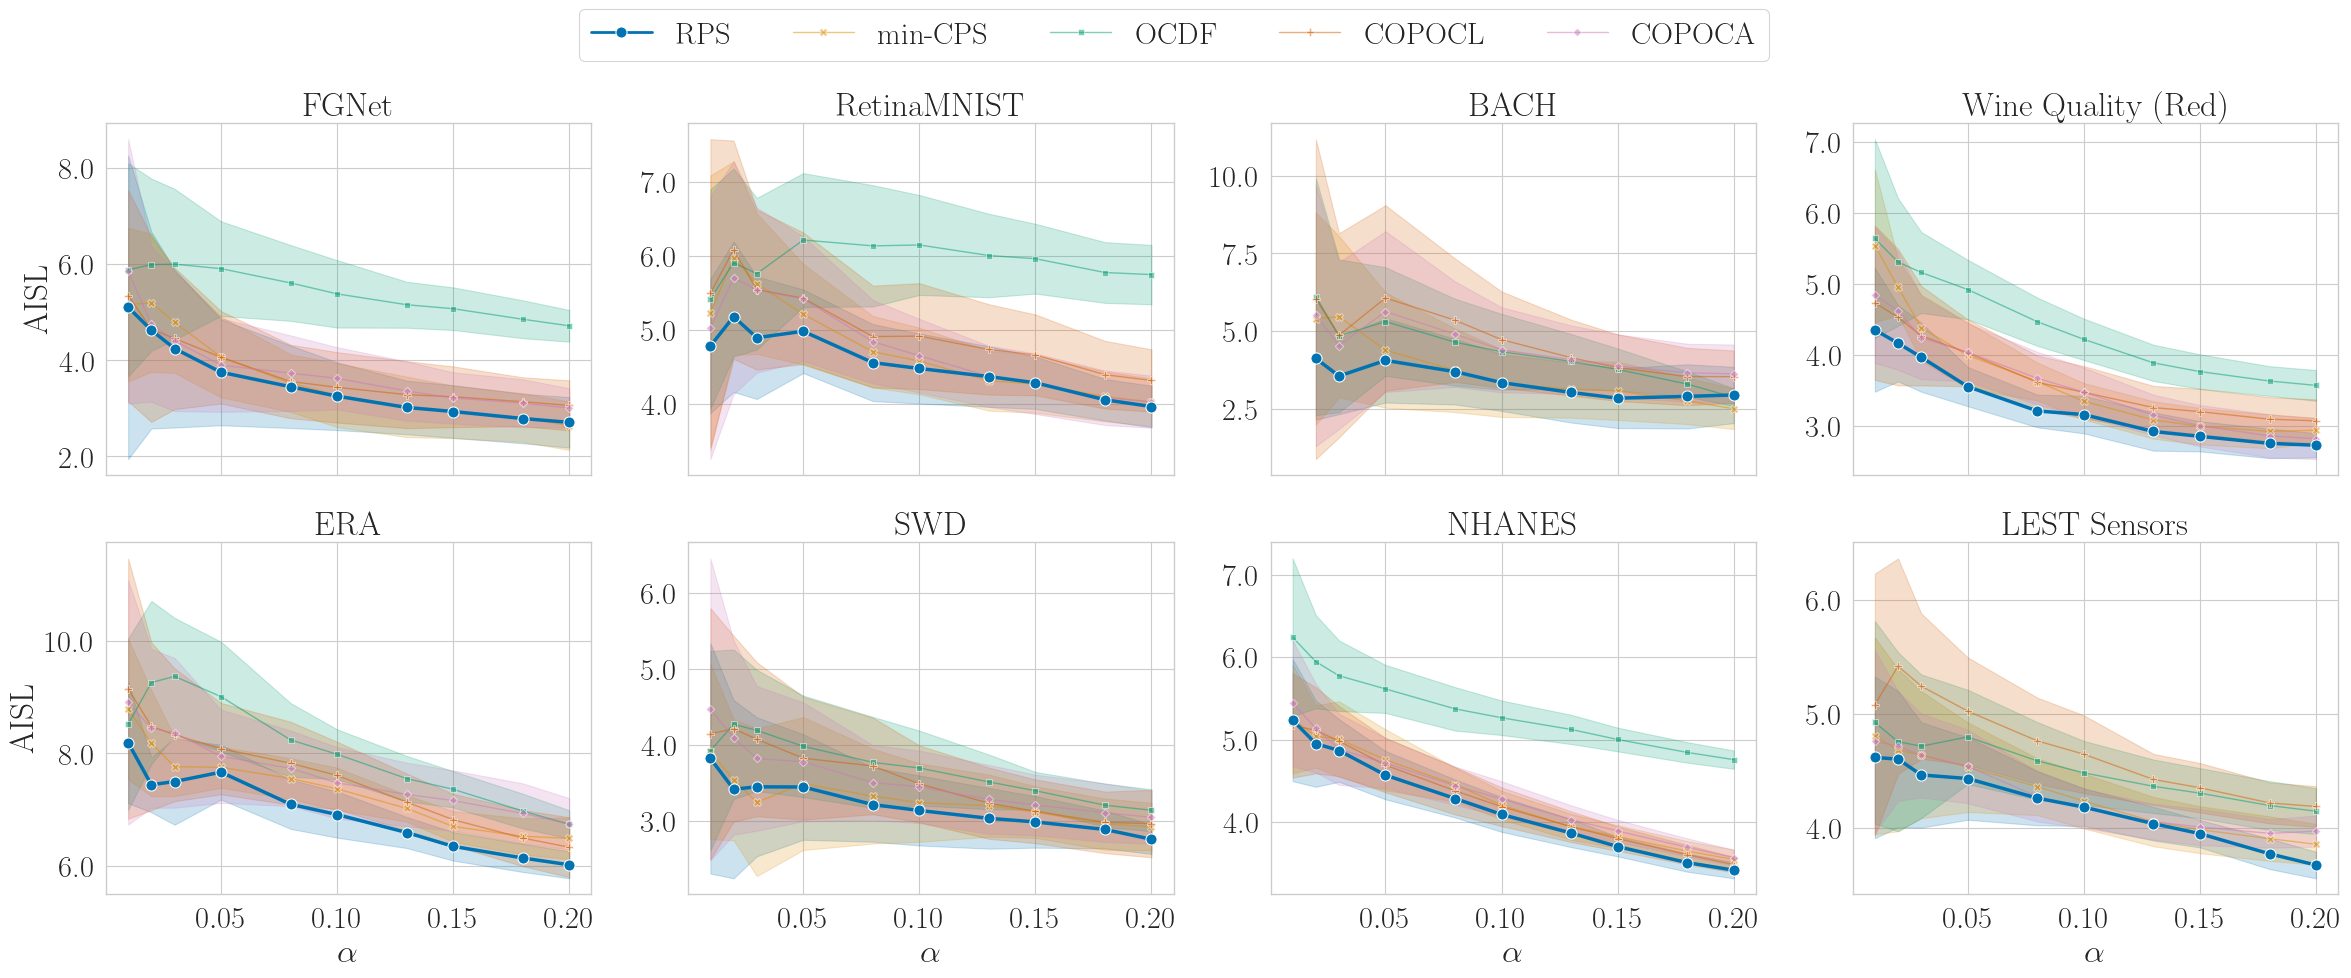

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(context='paper', style='whitegrid', font_scale=2.5, font="serif", rc={
    "text.usetex": True,
    "lines.markersize": 8,
    "lines.linewidth": 3
})

metric = 'AISL'

datasets = [
    "fgnet",
    "retina",
    "bach",
    "winequalityRed",
    #"lev",
    "era",
    "swd",
    "nhanes",
    "LESTSensors",
   #"insurance"
]

# Load and combine all datasets
frames = []
for dataset in datasets:
    df = pd.read_csv(f'./results/{dataset}_experiments_cp.csv')
    df['Dataset'] = dataset
    frames.append(df)

experiments_cp_df = pd.concat(frames, ignore_index=True)

# Define methods
experiments_cp_df['Method'] = ""
experiments_cp_df.loc[(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'LAC'), 'Method'] = 'LAC'
experiments_cp_df.loc[(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'APS'), 'Method'] = 'APS'
experiments_cp_df.loc[(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'RPS'), 'Method'] = 'RPS'
experiments_cp_df.loc[(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'min-CPS'), 'Method'] = 'min-CPS'
experiments_cp_df.loc[(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'OCDF'), 'Method'] = 'OCDF'
experiments_cp_df.loc[(experiments_cp_df['loss'] == 'COPOC') & (experiments_cp_df['score'] == 'LAC'), 'Method'] = 'COPOCL'
experiments_cp_df.loc[(experiments_cp_df['loss'] == 'COPOC') & (experiments_cp_df['score'] == 'APS'), 'Method'] = 'COPOCA'

print(experiments_cp_df['Method'].value_counts())

methods = ['LAC', 'APS', 'RPS', 'min-CPS', 'OCDF', 'COPOCL', 'COPOCA']

dataset_labels = {
    "fgnet": "FGNet",
    "retina": "RetinaMNIST",
    "bach": "BACH",
    "winequalityRed": "Wine Quality (Red)",
    "era": "ERA",
    "swd": "SWD",
    "nhanes": "NHANES",
    "LESTSensors": "LEST Sensors",
    "insurance": "Insurance",
    "lev": "LEV"
}

condition = experiments_cp_df['Method'].isin(methods)
df_filt = experiments_cp_df[condition].copy()

# Plot AISL across datasets
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=False)
axes = np.array(axes).ravel()





i = 0
for ax, dataset_name in zip(axes, datasets):
    df_ds = df_filt[df_filt["Dataset"] == dataset_name]



    g = sns.lineplot(
        data=df_ds,
        x="ALPHA", y=metric, hue="Method", style="Method",
        markers=True, errorbar='sd',palette="colorblind",
        hue_order=plot_methods, style_order=plot_methods, ax=ax, dashes=False
    )

    for line in ax.get_lines():
        line.set_markersize(6)
        line.set_alpha(0.5)
        line.set_linewidth(1)

    for line, label in zip(ax.get_lines(), plot_methods):
        if label == "RPS":
            line.set_markersize(8)
            line.set_linewidth(2.5)
            line.set_alpha(1.0)
            line.set_zorder(10)

    ax.set_xlabel(r'$\alpha$')

    if i % 4 == 0:
        ax.set_ylabel(metric)
    else:
        ax.set_ylabel('')
    ax.set_title(dataset_labels.get(dataset_name, dataset_name))
    ax.get_legend().remove()
    i += 1

    current_values = ax.get_yticks()
    ax.set_yticklabels(['{:.1f}'.format(x) for x in current_values])

handles, labels = axes[0].get_legend_handles_labels()
for h, l in zip(handles, labels):
    if l == "RPS":
        h.set_markersize(8)
        h.set_linewidth(2)
        h.set_alpha(1.0)

fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True, bbox_to_anchor=(0.5, 1.01))

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'{metric}_across_datasets.pdf', bbox_inches='tight', dpi=300)
plt.show()

